In [7]:
import sys, os, glob
sys.path.append('../../')
import numpy as np
from numpy.linalg import norm
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.colors import LogNorm

from IPython.display import display, Markdown
from collections import OrderedDict
import pylhe
import pyslha
import xml.etree.ElementTree as ET
from ROOT import TFile, TH1F, TCanvas
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d,griddata
from scipy.interpolate import interp1d,LinearNDInterpolator,NearestNDInterpolator
from scipy.interpolate import *
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib as mpl
import seaborn as sns
#sns.set_context('paper', font_scale=1.8) "font.family": "sans-serif","font.sans-serif": ["Helvetica"],
sns.set(style="white", context="paper", font_scale=1.8, 
        rc={"text.usetex": True, 
            'font.family':'Times New Roman', 
            'font.serif':'Times New Roman', 
            "savefig.dpi": 300})
plt.rcParams['text.usetex'] = True
def configure_axes(ax, info=None):   
    if info is not None:
        multiline_info = "\n".join(info)
        ax.text(0.2, 0.5, multiline_info, transform=ax.transAxes, fontsize=16,
                color='black', bbox=dict(facecolor='silver', alpha=0.5,
                                         edgecolor='silver', boxstyle='round,pad=0.8',
                                         linewidth=0.2))
    def set_x_label(label, size=18, labelpad=5):
        ax.set_xlabel(label, size=size, labelpad=labelpad, loc="right", fontname='serif')
    def set_y_label(label, size=18, labelpad=5):
        ax.set_ylabel(label, size=size, labelpad=labelpad, loc="top", fontname='serif')
    def set_legend(framealpha=0.5, fontsize='16'):
        ax.legend(framealpha=framealpha, loc='best', fontsize=fontsize)
    ax.set_x_label = set_x_label
    ax.set_y_label = set_y_label
    ax.minorticks_on() 
    ax.tick_params(direction='in', length=10, width=1.1, colors='black', which='major', top=True, right=True)
    ax.tick_params(direction='in', length=5, width=0.6, colors='black', which='minor', top=True, right=True)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    for spine in ['left', 'right', 'top', 'bottom']:
        ax.spines[spine].set_linewidth(1.2)
    sns.despine(left=False, bottom=False, right=False, top=False, offset=None, trim=False)
    ax.tick_params(axis='x', labelcolor='black', labelsize=16)
    ax.tick_params(axis='y', labelcolor='black', labelsize=16)
cm = mpl.colormaps['coolwarm']


# Digitalized data 

In [8]:
DFdata = pd.read_csv('fig_aux17b_digitalized_data.csv')
my0 = DFdata.iloc[:, 0].to_numpy()
mx = DFdata.iloc[:, 1].to_numpy()
UL_signal_strength = DFdata.iloc[:,2].to_numpy()
DFdata.head(5)


,Mediator Mass (GeV),DM Mass (GeV),Upper limit on signal strength
0,10,5,0.49
1,10,50,19.50
2,10,150,68.90
3,50,1,0.58
4,50,10,0.57


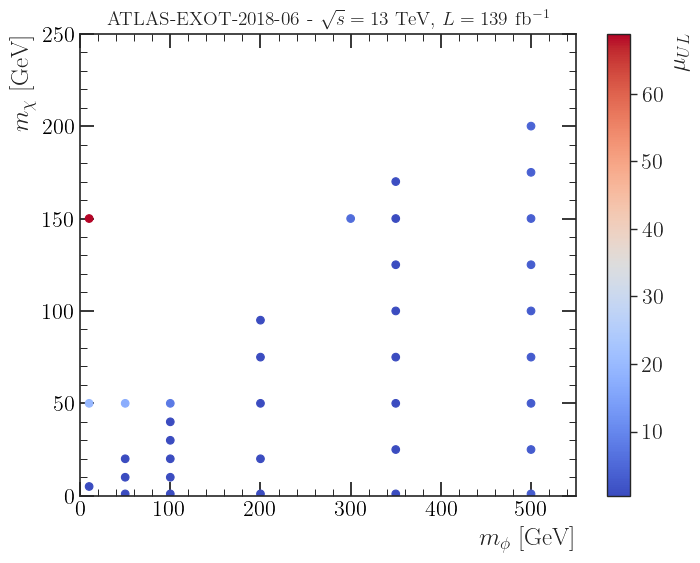

In [9]:
xsec = DFdata['Upper limit on signal strength']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(DFdata['Mediator Mass (GeV)'], DFdata['DM Mass (GeV)'], 
                c=xsec, cmap=cm,s=30) # vmin=5e-1, vmax=1.5e0
cbar = plt.colorbar(sc)
cbar.set_label(r'$\mu_{UL}$', loc='top')
ax.set_x_label(r'$m_{\phi}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# Signal Data from MadGraph5 Simulation

In [10]:
def process_pattern(pattern):
    """
    Process events from LHE files for a given pattern and calculates parameters.
    """
    run_numbers = glob.glob(f"{pattern}/run_*")
    new_keys = [f"Run {i}" for i in range(1, len(run_numbers) + 1)]
    sortedInputFiles = {key: f"{run_number}/unweighted_events.lhe.gz" for key, run_number in zip(new_keys, run_numbers)}
    parameters = {}
    
    for label, f in sortedInputFiles.items():
        banner_files = sorted(glob.glob(os.path.dirname(f) + '/*banner.txt'), key=os.path.getmtime, reverse=True)
        if not banner_files:
            continue
        banner = banner_files[0]
        xtree = ET.parse(banner)
        xroot = xtree.getroot()
        slha_text = xroot.find('header').find('slha').text
        xsec = float(xroot.find('header').find('MGGenerationInfo').text.split('#  Integrated weight (pb)')[-1].strip().strip(':').strip())
        pars = pyslha.readSLHA(slha_text, ignoreblocks=['QNUMBERS'])
        
        mDM = gSx = gPx = gPq = gSq = None
        BRs = {}
        if 54 in pars.blocks['MASS']:
            model = 'spin0'
            mMed = pars.blocks['MASS'][54]  # PHI prime mass
            mDM = pars.blocks['MASS'][52]  # DM mass
            gSx = pars.blocks['DMINPUTS'][3]  # coupling of mediators to DM
            gPx = pars.blocks['DMINPUTS'][4] # coupling of mediators to DM
            gPq = pars.blocks['DMINPUTS'][11]  # coupling of mediators to SM
            gSq = pars.blocks['DMINPUTS'][5]  # coupling of mediators to SM
            WMed = pars.decays[54].totalwidth  # Z prime width
            
            for decay in pars.decays[54].decays:
                if set(decay.ids) == {52,- 52} or set(decay.ids) == {6, -6}:
                    BRs[f"{decay.ids}"] = decay.br
                                
        
        if model in ['spin0']:
            parameters[label] = {
                'xsec': xsec,
                'mMed': mMed,
                'WMed': WMed,
                'mDM': mDM,
                'gPx': gPx,
                'gSx': gSx,
                'gPq': gPq,
                'gSq': gSq,
                'BRs': BRs
            }
    return parameters

DF_S = []
patterns = ['/home/yoxara/Insync/DMSimp_DMP_fig17b/Events']
for pattern in patterns:
    parameters = process_pattern(pattern)
    for label, params in parameters.items():
        data = {
            'Label': f'{label}',
            'signal sigma (pb)': params['xsec'],
            'Mediator Mass (GeV)': params['mMed'],
            'Mediator Width (GeV)': params['WMed'],
            'DM Mass (GeV)': params['mDM'],
            'gPx': params['gPx'],
            'gPq': params['gPq'],
        }
        for decay_channel, br in params['BRs'].items():
            data[f'BR_{decay_channel}'] = br
        DF_S.append(data)

DFsignal = pd.DataFrame(DF_S)
DFsignal['Mediator Mass (GeV)'] = DFsignal['Mediator Mass (GeV)'].round(1)
DFsignal.to_csv('MG5_signal_data.csv', index=False)
DFsignal
# PDG 52 is DM
# PDG 6 is t


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]"
0,Run 1,1234.2000,10.0,0.000000,5.0,1.0,1.0,NaN,NaN
1,Run 2,1235.4000,10.0,0.000000,150.0,1.0,1.0,NaN,NaN
2,Run 3,14.6110,300.0,0.003222,150.0,1.0,1.0,NaN,NaN
3,Run 4,26.4360,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755
4,Run 5,75.3640,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN
5,Run 6,22.5140,200.0,7.796968,20.0,1.0,1.0,1.000000,NaN
6,Run 7,4.2145,500.0,35.343440,175.0,1.0,1.0,0.401982,0.598018
7,Run 8,4.1766,500.0,33.072640,200.0,1.0,1.0,0.360921,0.639079
8,Run 9,4.1830,500.0,40.628440,50.0,1.0,1.0,0.479773,0.520227
9,Run 10,75.0970,100.0,3.183099,30.0,1.0,1.0,1.000000,NaN


In [11]:
DFsignal = pd.read_csv('MG5_signal_data.csv')
DFsignal.head(5)


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]"
0,Run 1,1234.200,10.0,0.000000,5.0,1.0,1.0,NaN,NaN
1,Run 2,1235.400,10.0,0.000000,150.0,1.0,1.0,NaN,NaN
2,Run 3,14.611,300.0,0.003222,150.0,1.0,1.0,NaN,NaN
3,Run 4,26.436,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755
4,Run 5,75.364,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN


# Merged data


In [12]:
merged_df = pd.merge(DFsignal,DFdata, on=['Mediator Mass (GeV)', 'DM Mass (GeV)'], how='inner')
merged_df = merged_df.drop_duplicates(subset=['Label'])
merged_df.head(5)


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]",Upper limit on signal strength
0,Run 1,1234.200,10.0,0.000000,5.0,1.0,1.0,NaN,NaN,0.49
1,Run 2,1235.400,10.0,0.000000,150.0,1.0,1.0,NaN,NaN,68.90
2,Run 3,14.611,300.0,0.003222,150.0,1.0,1.0,NaN,NaN,5.82
3,Run 4,26.436,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755,0.58
4,Run 5,75.364,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN,0.62


### Cross-section

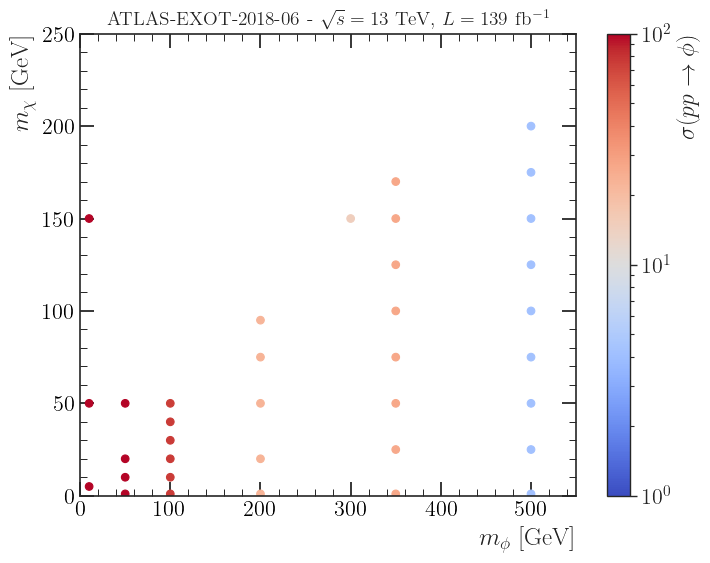

In [13]:
xsec = merged_df['signal sigma (pb)']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], 
                c=xsec, cmap=cm,s=30, norm = LogNorm(1,1e2)) # vmin=5e-1, vmax=1.5e0
cbar = plt.colorbar(sc)
cbar.set_label(r'$\sigma(p p \to \phi)$', loc='top')
ax.set_x_label(r'$m_{\phi}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


### Branching ratio

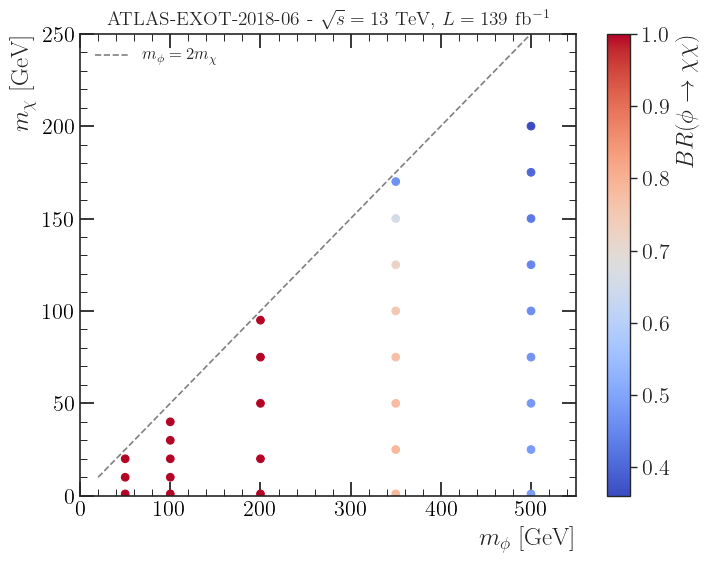

In [14]:
br = merged_df['BR_[-52, 52]']
x = np.linspace(20, 600, 1000)
y = x / 2
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=br, cmap=cm,s=30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{\phi} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$BR(\phi \to \chi \chi)$', loc='top')
ax.set_x_label(r'$m_{\phi}$ [GeV]')
ax.set_y_label(r'$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# $\frac{\Gamma_{\phi}}{m_{\phi}}$

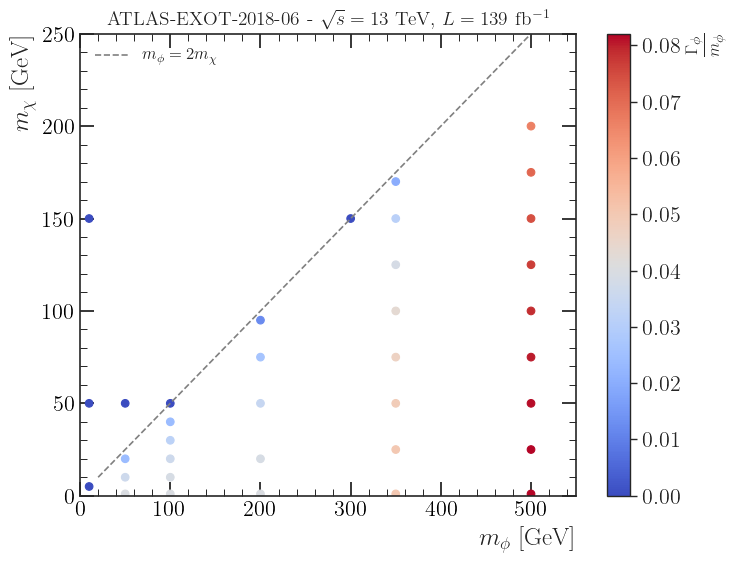

In [15]:
width_mass_ratio = merged_df['Mediator Width (GeV)'] / merged_df['Mediator Mass (GeV)']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=width_mass_ratio, cmap=cm,s=30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{\phi} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\frac{\Gamma_{\phi}}{m_{\phi}}$', loc='top')
ax.set_x_label('$m_{\phi}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


#### Exclude points with $BR(\phi \to \chi \chi) = 0$

In [16]:
merged_df = merged_df.dropna(subset=["BR_[-52, 52]"])
merged_df.head(5)


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]",Upper limit on signal strength
3,Run 4,26.4360,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755,0.58
4,Run 5,75.3640,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN,0.62
5,Run 6,22.5140,200.0,7.796968,20.0,1.0,1.0,1.000000,NaN,0.71
6,Run 7,4.2145,500.0,35.343440,175.0,1.0,1.0,0.401982,0.598018,3.76
7,Run 8,4.1766,500.0,33.072640,200.0,1.0,1.0,0.360921,0.639079,4.32


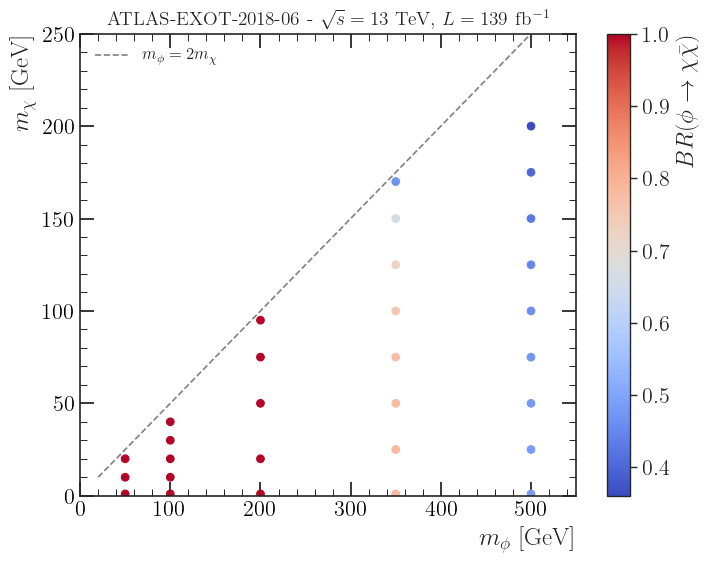

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=merged_df['BR_[-52, 52]'], cmap=cm,s=30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{\phi} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$BR(\phi\to \chi \bar{\chi})$', loc='top')
ax.set_x_label('$m_{\phi}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


In [18]:
merged_df = merged_df.dropna(subset=["BR_[-52, 52]"])
merged_df.head(5)


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]",Upper limit on signal strength
3,Run 4,26.4360,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755,0.58
4,Run 5,75.3640,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN,0.62
5,Run 6,22.5140,200.0,7.796968,20.0,1.0,1.0,1.000000,NaN,0.71
6,Run 7,4.2145,500.0,35.343440,175.0,1.0,1.0,0.401982,0.598018,3.76
7,Run 8,4.1766,500.0,33.072640,200.0,1.0,1.0,0.360921,0.639079,4.32


# $\frac{\Gamma_{\phi}}{m_{\phi}}$

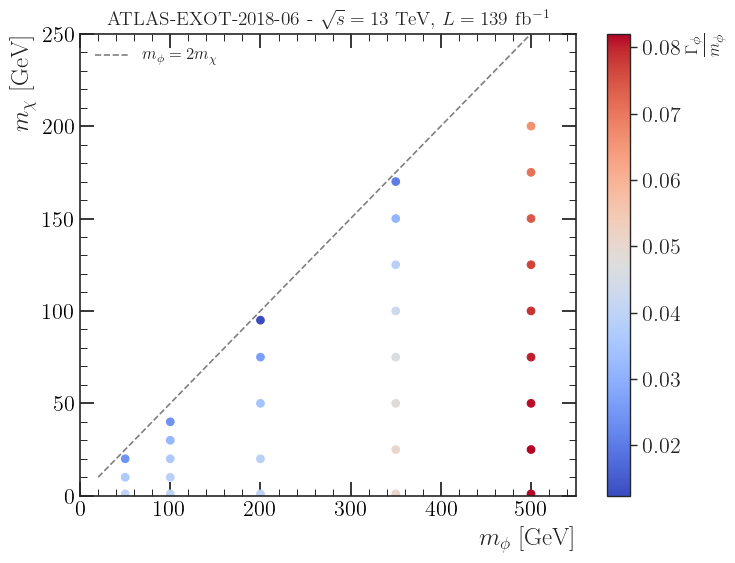

In [19]:
width_mass_ratio = merged_df['Mediator Width (GeV)'] / merged_df['Mediator Mass (GeV)']
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(merged_df['Mediator Mass (GeV)'], merged_df['DM Mass (GeV)'], c=width_mass_ratio, cmap=cm,s=30) # vmin=5e-1, vmax=1.5e0
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{\phi} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\frac{\Gamma_{\phi}}{m_{\phi}}$', loc='top')
ax.set_x_label('$m_{\phi}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()


# get  upper limits for $\sigma \times BR_{(Med \to \chi \chi)}$.

In [20]:
merged_df['xsecUL'] = merged_df['signal sigma (pb)'] * merged_df['Upper limit on signal strength']*merged_df['BR_[-52, 52]']
merged_df.head(5)


,Label,signal sigma (pb),Mediator Mass (GeV),Mediator Width (GeV),DM Mass (GeV),gPx,gPq,"BR_[-52, 52]","BR_[-6, 6]",Upper limit on signal strength,xsecUL
3,Run 4,26.4360,350.0,17.104310,50.0,1.0,1.0,0.780245,0.219755,0.58,11.963398
4,Run 5,75.3640,100.0,3.646698,20.0,1.0,1.0,1.000000,NaN,0.62,46.725680
5,Run 6,22.5140,200.0,7.796968,20.0,1.0,1.0,1.000000,NaN,0.71,15.984940
6,Run 7,4.2145,500.0,35.343440,175.0,1.0,1.0,0.401982,0.598018,3.76,6.370014
7,Run 8,4.1766,500.0,33.072640,200.0,1.0,1.0,0.360921,0.639079,4.32,6.512071


# DataFrame containing upper limits for $\sigma \times BR_{(Med \to \chi \chi)}$ and masses

In [21]:
new_df = merged_df[['Mediator Mass (GeV)', 'DM Mass (GeV)', 'xsecUL']]
new_headers = new_df.columns.tolist()
new_headers[0] = '# ' + new_headers[0]
new_df.columns = new_headers
new_df = new_df.dropna() 
new_df.to_csv('sigma_upper_limit_converted.csv', index=False)
new_df.head(5)


,# Mediator Mass (GeV),DM Mass (GeV),xsecUL
3,350.0,50.0,11.963398
4,100.0,20.0,46.725680
5,200.0,20.0,15.984940
6,500.0,175.0,6.370014
7,500.0,200.0,6.512071


# $\sigma_{UL}$ plot

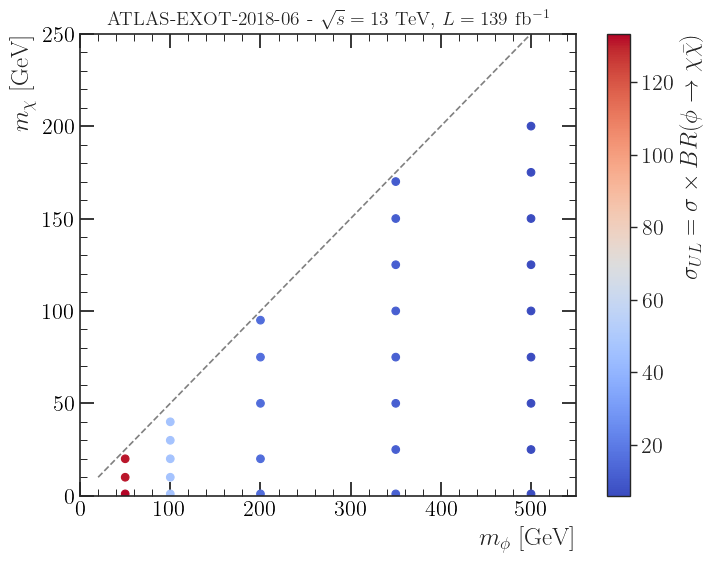

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))
configure_axes(ax)
sc = ax.scatter(new_df['# Mediator Mass (GeV)'], new_df['DM Mass (GeV)'], c=new_df['xsecUL'], cmap=cm,s=30)#, vmin = 0.3,vmax=1.0,) # 
ax.plot(x, y, color='gray', linestyle='--', label=r'$m_{\phi} = 2 m_{\chi}$')
cbar = plt.colorbar(sc)
cbar.set_label(r'$\sigma_{UL} = \sigma \times BR(\phi\to \chi \bar{\chi})$', loc='top')
ax.set_x_label('$m_{\phi}$ [GeV]')
ax.set_y_label('$m_{\chi}$ [GeV]')
ax.set_xlim(0, 550)
ax.set_ylim(0, 250)
#ax.legend(framealpha=0.0, fontsize='x-small')
plt.title(r'ATLAS-EXOT-2018-06 - $\sqrt{s} = 13$ TeV, $L = 139$ fb$^{-1}$', fontsize=14)
plt.show()
